In [1]:
import pandas as pd

In [3]:
url="https://raw.githubusercontent.com/JoelRomero123/PARCIAL4-JOEL-ROMERO-2523552017/refs/heads/main/clave_H_agrupacion.csv"
df=pd.read_csv(url)
 #Mostrar las primeras filas del dataset y explicar su estructura.
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       258 non-null    object 
 1   edad              258 non-null    int64  
 2   ingresos          258 non-null    int64  
 3   frecuencia_uso    258 non-null    float64
 4   gasto_promedio    258 non-null    float64
 5   satisfaccion      257 non-null    float64
 6   reclamos          258 non-null    int64  
 7   antiguedad_meses  258 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 16.3+ KB


In [6]:
#Selección y Preprocesamiento de Variables para Clustering
from sklearn.preprocessing import StandardScaler

# Identificar características numéricas relevantes para el clustering
# 'registro_id' es un identificador y no es adecuado para el clustering
clustering_features = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']

# Crear una copia del DataFrame para el clustering para evitar modificar el df original
df_clustering = df[clustering_features].copy()

# Manejar valores faltantes en 'satisfaccion' imputándolos con la media
# Basado en df.info(), 'satisfaccion' tiene 1 valor faltante
df_clustering['satisfaccion'] = df_clustering['satisfaccion'].fillna(df_clustering['satisfaccion'].mean())

# Inicializar el StandardScaler
scaler = StandardScaler()

# Escalar las características
df_scaled = scaler.fit_transform(df_clustering)

# Convertir el array escalado de nuevo a un DataFrame para un manejo más fácil
df_scaled = pd.DataFrame(df_scaled, columns=clustering_features)

print("Primeras 5 filas de los datos escalados:")
display(df_scaled.head())

Primeras 5 filas de los datos escalados:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,0.702228,0.385652,1.378570,1.499559,0.817973,-1.218790,1.416909
1,-0.175841,-0.933803,0.380390,-0.242766,-2.166959,1.775951,-1.246570
2,-0.370967,-0.047400,-0.555404,-0.119021,-1.789742,0.777704,-1.024614
3,-0.566093,-1.215738,-0.822279,-0.839258,-0.969706,4.770692,-0.728672
4,-0.370967,0.157849,0.359594,-0.614416,0.550094,-0.719666,0.381112


### Método del Codo para Determinar el Número Óptimo de Clústeres

El método del codo es una heurística utilizada para determinar el número óptimo de clústeres en un conjunto de datos. Consiste en ejecutar el algoritmo de clustering K-Means para un rango de valores de K (número de clústeres) y para cada K, calcular la suma de cuadrados dentro del clúster (WCSS, del inglés 'Within-Cluster Sum of Squares'). El WCSS es la suma de las distancias al cuadrado de cada punto a su centroide asignado. Se espera que, a medida que K aumenta, el WCSS disminuya. El 'codo' se refiere al punto en el gráfico donde la tasa de disminución del WCSS cambia abruptamente, lo que sugiere que añadir más clústeres más allá de ese punto no proporciona una mejora sustancial en la compactación de los clústeres.

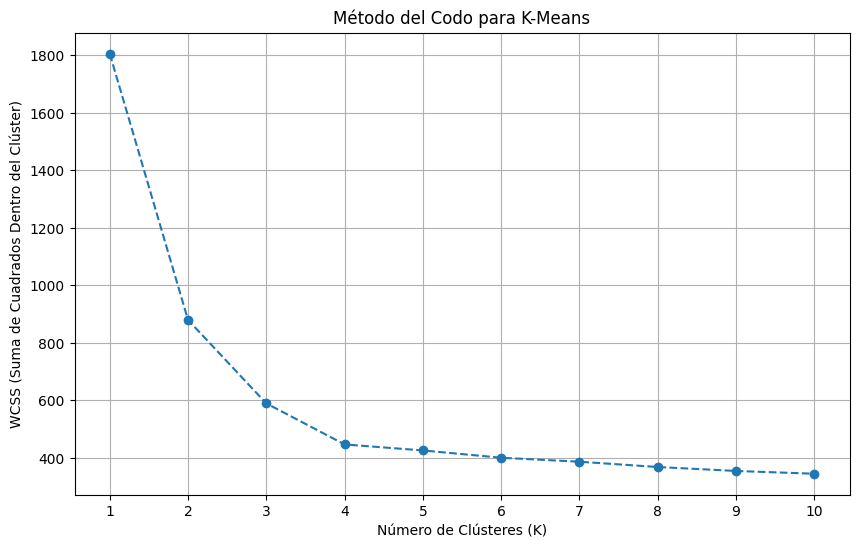

Observa el gráfico para identificar el 'codo', que sugiere el número óptimo de clústeres.


In [7]:
#Metodo del codo
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Definir un rango de números de clústeres a probar (ej. de 1 a 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('WCSS (Suma de Cuadrados Dentro del Clúster)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Observa el gráfico para identificar el 'codo', que sugiere el número óptimo de clústeres.")

### Aplicación del Algoritmo K-Means

Una vez que hemos determinado el número óptimo de clústeres utilizando el método del codo (en este caso, seleccionaremos 4 clústeres como punto de partida), procederemos a aplicar el algoritmo K-Means a nuestros datos escalados. K-Means asignará cada punto de datos a uno de los 4 clústeres, basándose en la proximidad de los puntos a los centroides de los clústeres.

In [8]:
from sklearn.cluster import KMeans

# Asumiendo que el número óptimo de clústeres es 4 (basado en la observación del codo)
optimal_clusters = 4

# Aplicar K-Means con el número óptimo de clústeres
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Añadir las etiquetas de los clústeres al DataFrame original
df['cluster'] = clusters

print(f"Se han creado {optimal_clusters} clústeres.")
print("Primeras 5 filas del DataFrame con las etiquetas de clúster:")
display(df.head())

Se han creado 4 clústeres.
Primeras 5 filas del DataFrame con las etiquetas de clúster:


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,H-R0158,48,1292,9.60,158.47,8.45,0,37,2
1,H-R0209,39,707,6.72,73.85,2.99,6,1,3
2,H-R0257,37,1100,4.02,79.86,3.68,4,4,3
3,H-R0037,35,582,3.25,44.88,5.18,12,8,3
4,H-R0132,37,1191,6.66,55.80,7.96,1,23,0


### Análisis de los Clústeres

Una vez que se han asignado los clientes a clústeres, es crucial analizar las características de cada clúster para entender los perfiles de clientes que se han formado. Esto se logra examinando las estadísticas descriptivas (como la media) de las variables originales dentro de cada grupo. Esto nos permitirá darle un significado a cada clúster y potencialmente nombrar cada segmento.

In [10]:
# Calcular las estadísticas descriptivas para cada clúster
cluster_analysis = df.groupby('cluster')[clustering_features].mean()

print("Análisis de las características de cada clúster (medias):")
display(cluster_analysis)

# Opcionalmente, puedes calcular otras estadísticas si son relevantes
# cluster_median = df.groupby('cluster')[clustering_features].median()
# print("\nMedianas por clúster:")
# display(cluster_median)

Análisis de las características de cada clúster (medias):


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,38.704225,1117.690141,6.591690,86.681690,8.083380,1.253521,17.647887
1,29.000000,683.121212,2.389091,37.394091,6.028308,3.121212,5.075758
2,53.587302,1740.698413,9.090159,158.034286,8.801905,0.777778,36.523810
3,42.913793,950.275862,4.348793,60.632414,4.600690,4.931034,12.344828


/tmp/ipykernel_15659/4050658472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_analysis.index, y='satisfaccion', data=cluster_analysis, palette='viridis')


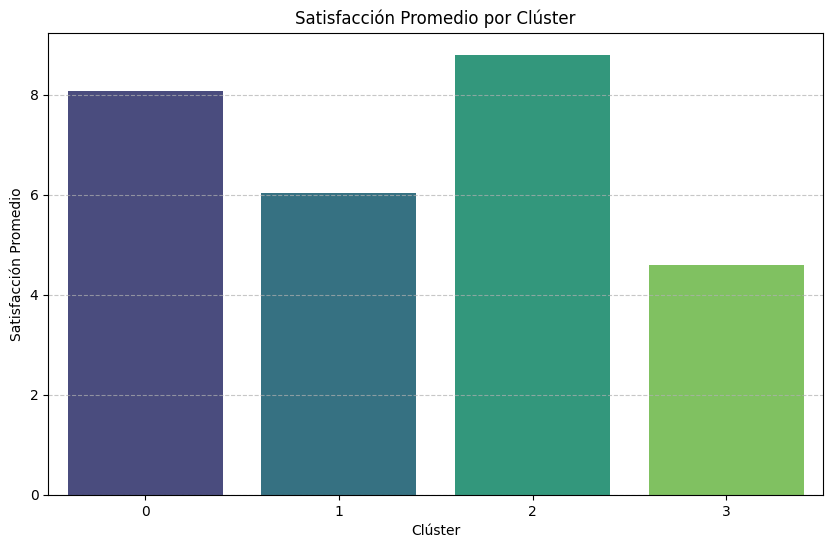

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para la satisfacción promedio por clúster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_analysis.index, y='satisfaccion', data=cluster_analysis, palette='viridis')
plt.title('Satisfacción Promedio por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Satisfacción Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

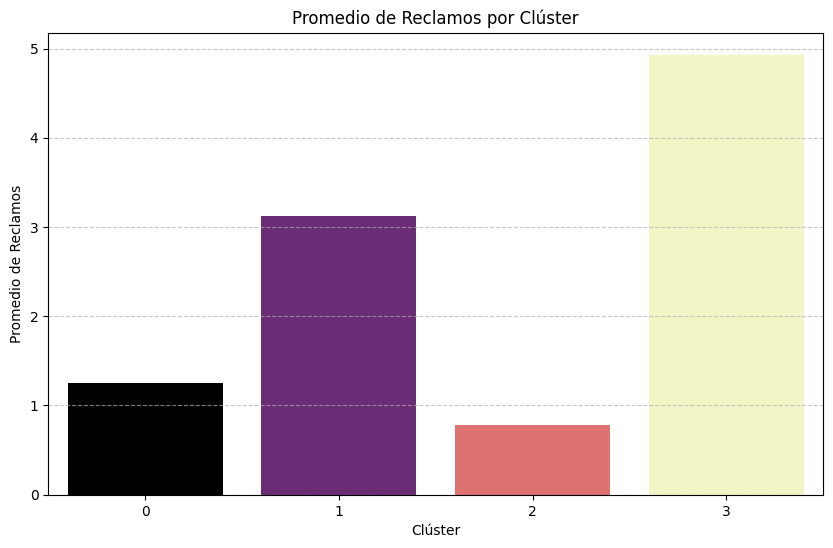

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para el promedio de reclamos por clúster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_analysis.index, y='reclamos', hue=cluster_analysis.index.name, data=cluster_analysis, palette='magma', legend=False)
plt.title('Promedio de Reclamos por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Promedio de Reclamos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

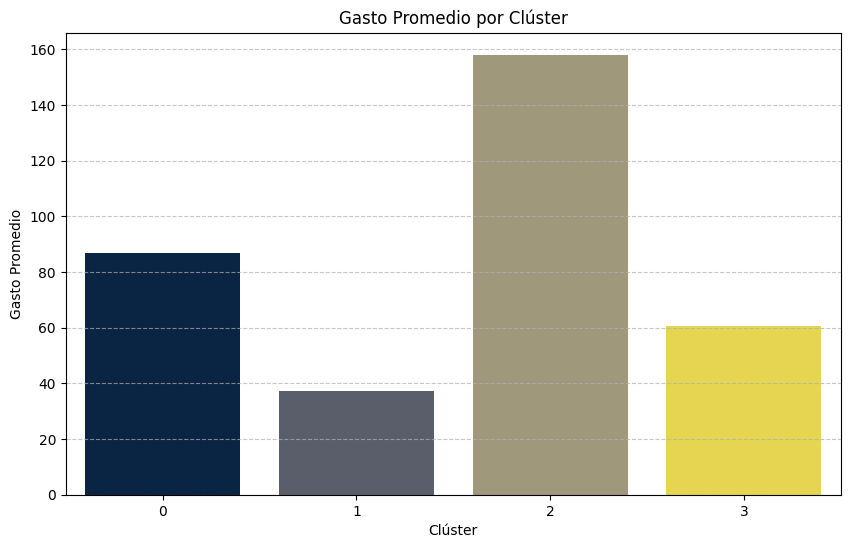

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para el promedio de gasto_promedio por clúster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_analysis.index, y='gasto_promedio', hue=cluster_analysis.index.name, data=cluster_analysis, palette='cividis', legend=False)
plt.title('Gasto Promedio por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Gasto Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

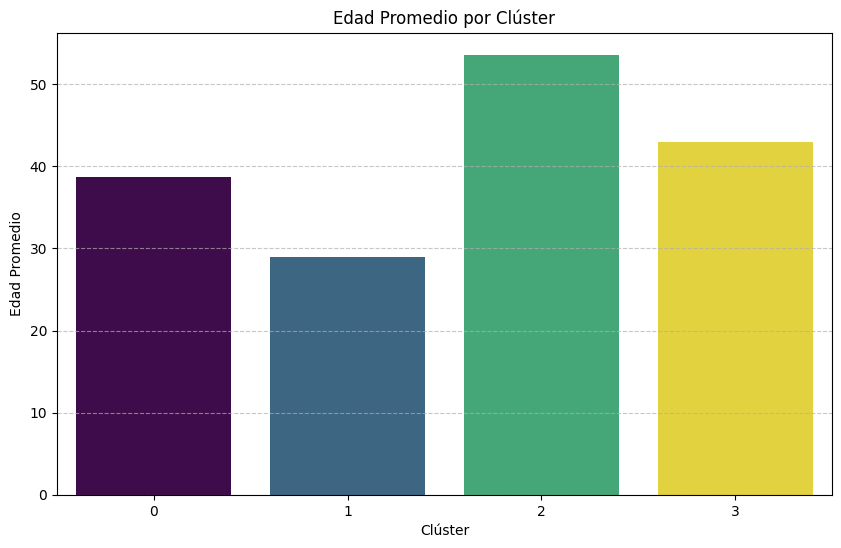

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para la edad promedio por clúster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_analysis.index, y='edad', hue=cluster_analysis.index.name, data=cluster_analysis, palette='viridis', legend=False)
plt.title('Edad Promedio por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Edad Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Este gráfico de barras te permite comparar la 'edad' promedio entre los clústeres. Puedes observar las diferencias en la distribución de edad de cada segmento de clientes, lo cual complementa el perfil de cada clúster. ¿Te gustaría visualizar alguna otra característica de los clústeres?

Este gráfico de barras te permite comparar el promedio de 'gasto_promedio' entre los clústeres. Puedes observar las diferencias en el comportamiento de gasto de cada segmento de clientes, lo cual es fundamental para estrategias de marketing y ventas diferenciadas. ¿Hay alguna otra característica que te gustaría visualizar?

Este gráfico de barras te permite ver rápidamente las diferencias en el promedio de reclamos entre los clústeres. Como puedes observar, el Clúster 3 ('Clientes Frustrados de Riesgo') tiene el promedio más alto de reclamos, lo que concuerda con nuestra interpretación previa. ¿Hay alguna otra característica que te interese visualizar de esta manera?

Este gráfico de barras te permitirá visualizar claramente las diferencias en la satisfacción promedio entre los cuatro clústeres. Podrás identificar rápidamente qué grupos de clientes están más o menos satisfechos. ¿Hay alguna otra métrica que te gustaría visualizar de esta manera?

In [11]:
display(df.head())

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,H-R0158,48,1292,9.60,158.47,8.45,0,37,2
1,H-R0209,39,707,6.72,73.85,2.99,6,1,3
2,H-R0257,37,1100,4.02,79.86,3.68,4,4,3
3,H-R0037,35,582,3.25,44.88,5.18,12,8,3
4,H-R0132,37,1191,6.66,55.80,7.96,1,23,0


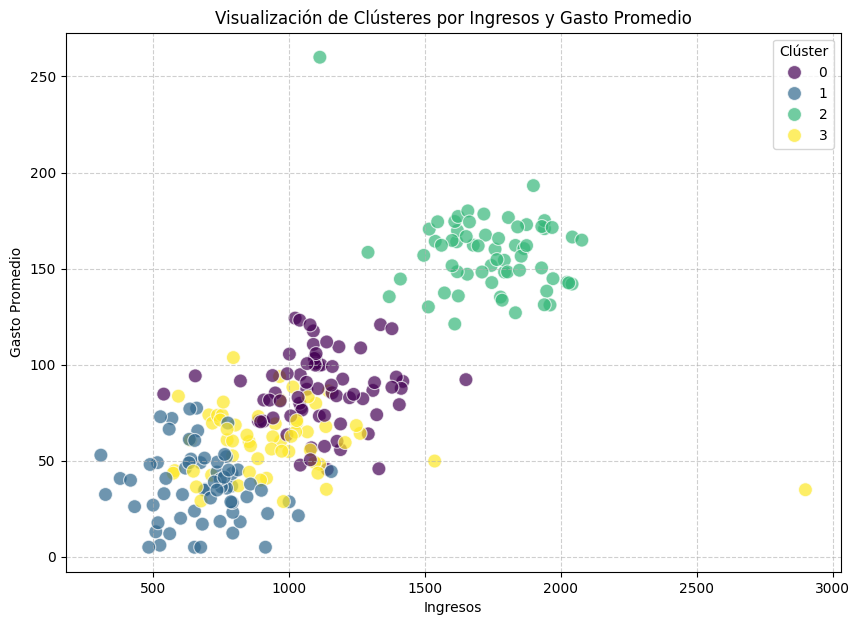

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(x='ingresos', y='gasto_promedio', hue='cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Visualización de Clústeres por Ingresos y Gasto Promedio')
plt.xlabel('Ingresos')
plt.ylabel('Gasto Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Clúster')
plt.show()

Este gráfico de dispersión nos ayuda a visualizar la separación entre los clústeres. Puedes observar cómo los clientes se agrupan en diferentes regiones según sus ingresos y gasto promedio, y cómo cada color representa un clúster distinto. ¿Te gustaría visualizar otros pares de características o quizás intentar una visualización 3D?